In [101]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker

In [102]:
Data = pd.read_excel('2.5.1 Data.xlsx')
table = pd.read_excel('Tablich 2.5.1.xlsx')
pgh = 80
d1 = 0.99
d2 = 1.1
t = Data['t']+273
s1 = (Data['p']-pgh)*1.9486*d1/4
s2 = (Data['p']-pgh)*1.9486*d2/4
Ttable = table['t']+273
st = table['s']

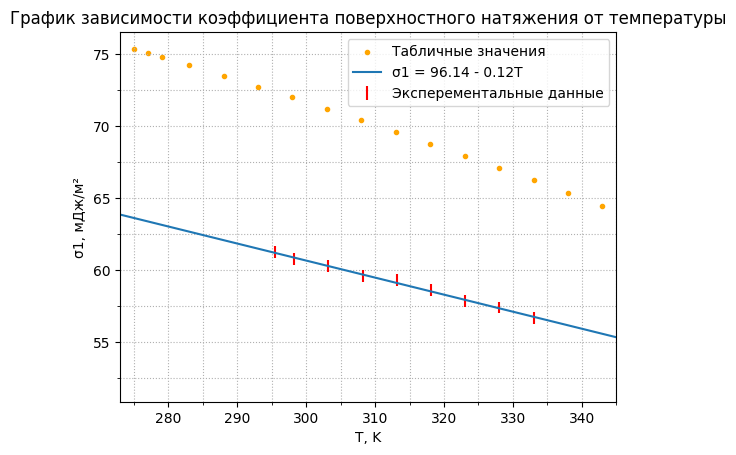

In [103]:
plt.errorbar(t, s1, label='Эксперементальные данные',yerr=list(map(lambda x: x*0.007, s1)), ecolor='red', color='none')
plt.scatter(Ttable, st, label='Табличные значения', marker='.', color='orange')
coeffs = np.polyfit(t, s1, deg=1)
poly_func = np.poly1d(coeffs)
x = np.linspace(273, 373, 1000)
y = poly_func(x)
plt.plot(x, y, label=f"σ1 = {coeffs[1]:.2f} - {abs(coeffs[0]):.2f}T")
ax = plt.gca()
ax.legend()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(2.5))
ax.grid(True, which='both', axis='both', linestyle='dotted')
ax.set_xlim(273, 345)
# ax.set_ylim(0, 16)
plt.title('График зависимости коэффициента поверхностного натяжения от температуры')
plt.xlabel("T, K")
plt.ylabel("σ1, мДж/м²")
plt.show()

In [104]:
dsdt1 = coeffs[0]
s01 = coeffs[1]

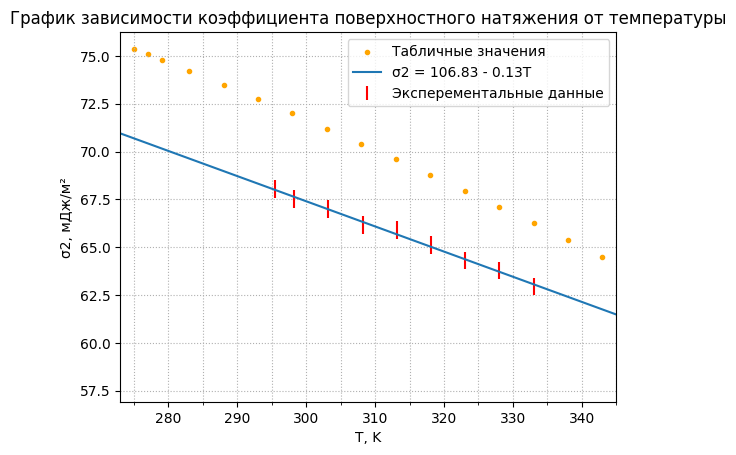

In [105]:
plt.errorbar(t, s2, label='Эксперементальные данные',yerr=list(map(lambda x: x*0.007, s2)), ecolor='red', color='none')
plt.scatter(Ttable, st, label='Табличные значения', marker='.', color='orange')
coeffs = np.polyfit(t, s2, deg=1)
poly_func = np.poly1d(coeffs)
x = np.linspace(273, 373, 1000)
y = poly_func(x)
plt.plot(x, y, label=f"σ2 = {coeffs[1]:.2f} - {abs(coeffs[0]):.2f}T")
ax = plt.gca()
ax.legend()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(2.5))
ax.grid(True, which='both', axis='both', linestyle='dotted')
ax.set_xlim(273, 345)
# ax.set_ylim(0, 16)
plt.title('График зависимости коэффициента поверхностного натяжения от температуры')
plt.xlabel("T, K")
plt.ylabel("σ2, мДж/м²")
plt.show()

In [106]:
dsdt2 = coeffs[0]
s02 = coeffs[1]

In [107]:
D_podgon=1.165
S_podgon = (Data['p']-pgh)*1.9486*D_podgon/4

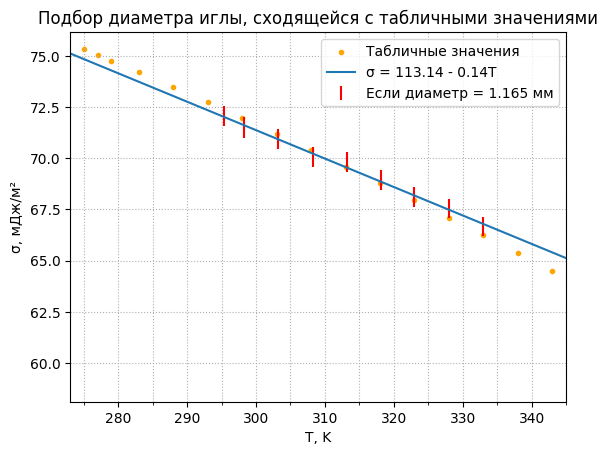

In [108]:
plt.errorbar(t, S_podgon, label='Если диаметр = 1.165 мм',yerr=list(map(lambda x: x*0.007, S_podgon)), ecolor='red', color='none')
plt.scatter(Ttable, st, label='Табличные значения', marker='.', color='orange')
coeffs = np.polyfit(t, S_podgon, deg=1)
poly_func = np.poly1d(coeffs)
x = np.linspace(273, 373, 1000)
y = poly_func(x)
plt.plot(x, y, label=f"σ = {coeffs[1]:.2f} - {abs(coeffs[0]):.2f}T")
ax = plt.gca()
ax.legend()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(2.5))
ax.grid(True, which='both', axis='both', linestyle='dotted')
ax.set_xlim(273, 345)
# ax.set_ylim(0, 16)
plt.title('Подбор диаметра иглы, сходящейся с табличными значениями')
plt.xlabel("T, K")
plt.ylabel("σ, мДж/м²")
plt.show()

D_podgon довольно сильно отличается от d1 и d2 (вне пределов погрешности)

Значит несходимость результатов измерений с табличными значениями может быть связана не только с погрешностью измерений. Есть какой-то иной фактор, например особенности иглы, об это еще может сообщать не соответствия наклонов графиков

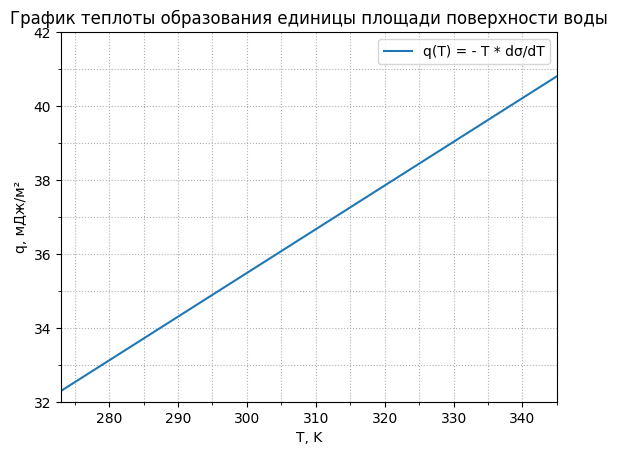

dσ/dT = -0.118


In [109]:
x = np.linspace(273, 373, 1000)
y = x*(-dsdt1)
plt.plot(x, y, label=f"q(T) = - T * dσ/dT")

ax = plt.gca()
ax.legend()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.grid(True, which='both', axis='both', linestyle='dotted')
ax.set_xlim(273, 345)
ax.set_ylim(32, 42)
plt.title('График теплоты образования единицы площади поверхности воды')
plt.xlabel("T, K")
plt.ylabel("q, мДж/м²")
plt.show()
print(f'dσ/dT = {dsdt1:.3f}')

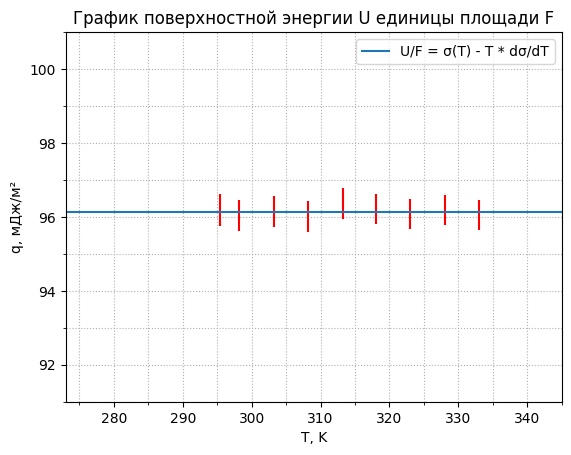

In [110]:
plt.errorbar(t, (s1-(t*dsdt1)), yerr=list(map(lambda x: x*0.007, s1)), ecolor='red', color='none')
coeffs = np.polyfit(t, (s1-(t*dsdt1)), deg=1)
poly_func = np.poly1d(coeffs)
x = np.linspace(273, 373, 1000)
y = poly_func(x)
plt.plot(x, y, label=f"U/F = σ(T) - T * dσ/dT")

ax = plt.gca()
ax.legend()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.grid(True, which='both', axis='both', linestyle='dotted')
ax.set_xlim(273, 345)
ax.set_ylim(91, 101)
plt.title('График поверхностной энергии U единицы площади F')
plt.xlabel("T, K")
plt.ylabel("q, мДж/м²")
plt.show()

In [111]:
data = {'T': Data['t'], 'S1' : s1, 'S2': s2}
data = pd.DataFrame(data)
print(data)

      T         S1         S2
0  22.4  61.249370  68.054855
1  25.2  60.767091  67.518990
2  30.2  60.284813  66.983125
3  35.2  59.561395  66.179328
4  40.2  59.320256  65.911395
5  45.1  58.596838  65.107598
6  50.0  57.873420  64.303800
7  55.0  57.391142  63.767935
8  60.0  56.667724  62.964138
